# Software engineering for reproducible workflows

<h1>Software engineering for reproducible workflows</h1>

<p>
<b>Quantitative Big Imaging - ETHZ: 227-0966-00L</b>
<br />
    
<div class='row'>
    <div class='column23'>
        <p style="font-size:1em;">April 30, 2026</p>
        <br /><br />
        <p style="font-size:1.5em;padding-bottom: 0.25em;">Anders Kaestner</p>  
        <p style="font-size:1em;">Laboratory for Neutron Scattering and Imaging<br />Paul Scherrer Institut</p>
    </div>
    <div class='column13'>
        <img src="../../docs/figures/np_combine_156599_000000.svg" style="height:300px" />
    </div>
</div> 
</p>


In [1]:
## Let's load some modules
%reload_ext autoreload
%autoreload 2
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
import numpy as np
import skimage.io as io
from scipy import linalg
import matplotlib as mpl
import pandas as pd

plt.rcParams["figure.figsize"] = (8, 8)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 14
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.style.use('default')
sns.set_style("whitegrid", {'axes.grid': False})

## Literature / Useful References

- Okken, B., [Python testing with pytest](https://pragprog.com/titles/bopytest2/python-testing-with-pytest-second-edition/)
- Wuttke, J. et al., [Guidelines for collaborative software development](http://dx.doi.org/10.3233/JNR-220002), 2022.
    

## Repeatable workflows
Repeatable workflows require some software engineering skills

From lecture 8

<img src="figures/diciplined_steps.svg" width=800 />

Repeatability requires that your code:
- is testable
- has a tracked history
- is reviewed
- is documented

... and keep track of bugs and new ideas in an issue manager.


```{figure} figures/diciplined_steps.png
---
width: 12cm
---
The outline of a bimodal imaging system for neutrons and X-rays. 
```

### Tools to support reproducible workflows
<br/>
<div class="row">
<div class="column13">
<img src="figures/np_node.svg" width="150px" />  
    
__Use a repository__
    
History management

</div>
<div class="column13">
<img src="figures/np_test.svg" width="150px" />
    
__Use automated tests__
    
Guarantees unit functionality

</div>
<div class="column13">
<img src="figures/np_continuous-deployment.svg" width="150px" />
    
__Use a build server__
    
Combines repository and tests
    

</div>
</div>

Each of these measures will be described in more detail in the following sections, but first a little introduction to what each step brings.

#### Repositories
Correctly used a source code repository helps you to keep track of your changes and also makes it possible to reproduce a result eventhough your code has evolved since you produced an earlier result. The repo also makes it possible to work on parallel ideas without ruining the main code. Hence, it gives you more freedom to be creative with less risk.

#### Automated tests
Automated tests are small programs written to verify that your main code actually does what it is supposed to do. This is a sanity check that is very helpful when you start working on different branches in your repository. The tests must always run successfully before you are allowed to merge a new piece of code into the main branch of your repository. 

#### Build server
A build server is set up to build and test the code you submit to the repository. This is particularly important when your project grows. For smaller projects it less relevant.

## How to organize the code

In this course, we have mainly implemented the analysis using python and in particular using jupyter notebooks. 

Notebooks are good for prototyping ... but are not good for
- structuring/maintenance 
- repositories
- portability/sharing
- testing

To achieve a cleaner workflow with your code it a good idea to separate common functions that are used often in many contexts onto library files. This has the advantage that the notebooks are cleaner and that a change in a function is propagated to all notebook using that function without having to copy the function between notebooks. Library files are also easier to access in testing frameworks.

Save functions in .py files which are imported

Your functions are saved in a file 'mylib.py'  
```python
import mylib

mylib.myfunction(1234)
```

Reload during development in a notebook
```python
import importlib
importlib.reload(mylib)
```

### Why reloading is used in notebooks:
In Jupyter, you might edit a module (say `mylib.py`). Reloading a library is essential here, otherwise the notebook doesn't know that you have updated you library functions. The reloading allows the notebook to **see changes without restarting the kernel**. Restarting is time consuming as you have to run the entire notebook again. 

Reloading modules is of course most important during the development phase. 

### Why it's not useful in scripts:
Reloading is naturally less relevant in end user notebooks or scripts.
* In a regular script:

  * The module is **imported once at runtime**.
  * The script **starts fresh each time**, so there's no need to "reload" — it loads from scratch every time anyway.
  
* Using `importlib.reload()` in a script is redundant unless you're dynamically loading modules in a very specialized case (e.g., plugin systems or hot-reload servers).

More advanced use of libraries is beyond the scope of this lecture, but it is well described in many books and online resources.

## Documentation

Documentation is a tedious task that many dread and leave to the end, if at all writing it with the motivation that "It's anyway only I who will use the code". This kind of reasoning is not very sustainable. Have you tried to take a look a your own code some months later? Did you instantaneously understand what it does and how is should be used?

There are different levels of documentation:

- In-code comments
- API (application programmer interface) describes which arguments and return values
- User documentation describes how the code is intended to be used.

API documentation is a minimum!

### API Documentation
#### Doc string in python

In [2]:
def fancy_function(value) :
    """ Description: Makes fantastic calculations

    Parameters:
    value (int): Description of argument

    Returns:
    int: Returning value

    """
    return 42+value

help(fancy_function)

Help on function fancy_function in module __main__:

fancy_function(value)
    Description: Makes fantastic calculations
    
    Parameters:
    value (int): Description of argument
    
    Returns:
    int: Returning value



#### Doxygen for many languages

https://www.doxygen.nl

## Unit Testing

In computer programming, unit testing is a method by which individual units of source code, sets of one or more computer program modules together with associated control data, usage procedures, and operating procedures, are tested to determine if they are fit for use.

- Intuitively, one can view a unit as the smallest testable part of an application
- Unit testing is possible with every language
- Most (Java, C++, Matlab, R, Python) have support for automated testing and reporting

- [Computational science: ... Error](http://doi.org/10.1038/467775a)
- [Unit testing guidelines](https://medium.com/@sachinsoni600517/unit-testing-in-python-a-comprehensive-guide-for-beginners-985eec71bb4d)

## Unit Testing - design
The first requirement for unit testing to work well is to have your code divided up into small independent parts (functions)
### What to test?
 - Each part can then be tested independently (unit testing)
     - If the tests are well done, units can be changed and tested independently
     - Makes upgrading or expanding tools _easy_
 - The entire path can be tested (integration testing)
     - Catches mistakes in integration or _glue_

### How to test
- The _happy path_ - check what it is supposed to do
- To __provoke__ your code - provide data that will fail execution

### Test data
Ideally with realistic but simulated test data

<div class="alert alert-success">
<center>The utility of the testing is only as good as the tests you make</center>
</div>

### A unit test example
Given the following function that counts all nonzero voxels in an image.
```python
def vxCnt=countVoxs(inImage)
```



We can write the following tests:

```python 
def testEmpty2d() :
    assert countVoxs(zeros(3,3)) == 0
```

```python
def testEmpty3d() :
    assert countVoxs(zeros(3,3,3)) == 0
```

```python 
def testDiag2d() :
    assert countVoxs(eye(3)) == 3
```

Unit tests can, as you see in this example, be quite trivial and that is the strength of the tests. They are fast to run and don't cost much waiting time and at the same time they also guarantee that the functionality is provided.

## Unit Testing: Example
Given the following function
```function shapeTable=shapeAnalysis(inImage)```

We should decompose the function into sub-components with single tasks:

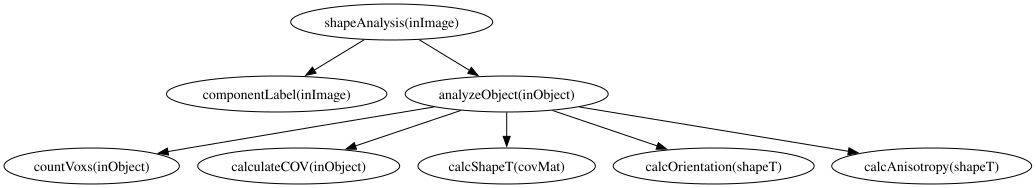

In [3]:
from graphviz import Digraph
dot = Digraph()
dot.edge('shapeAnalysis(inImage)', 'componentLabel(inImage)'), dot.edge('shapeAnalysis(inImage)', 'analyzeObject(inObject)')
dot.edge('analyzeObject(inObject)','countVoxs(inObject)'),     dot.edge('analyzeObject(inObject)','calculateCOV(inObject)')
dot.edge('analyzeObject(inObject)','calcShapeT(covMat)'),      dot.edge('analyzeObject(inObject)','calcOrientation(shapeT)')
dot.edge('analyzeObject(inObject)','calcAnisotropy(shapeT)')
dot

## Unit Testing in Python

### unittest
The built-in Python module, ideal for beginners due to its simplicity.

### PyTest
A popular framework known for its flexibility, advanced features, and readable style.
- well suited for larger projects 
- you make a set of specific tests for each module 
- run each time the project is updated. 

## Unit testing examples from Scikit Image
https://github.com/scikit-image/scikit-image/tree/master/skimage

- [Test Watershed](https://github.com/scikit-image/scikit-image/blob/16d3fd07e7d882d7f6b74e8dc4028ff946ac7e63/skimage/morphology/tests/test_watershed.py#L79)

- [Test Connected Components](https://github.com/scikit-image/scikit-image/blob/16d3fd07e7d882d7f6b74e8dc4028ff946ac7e63/skimage/morphology/tests/test_ccomp.py#L13)

```python
class TestWatershed(unittest.TestCase):
    eight = np.ones((3, 3), bool)

    def test_watershed01(self):
        "watershed 1"
        data = np.array([[0, 0, 0, 0, 0, 0, 0],
                            [0, 0, 0, 0, 0, 0, 0],
                            [0, 0, 0, 0, 0, 0, 0],
                               [0, 1, 1, 1, 1, 1, 0],
                               [0, 1, 0, 0, 0, 1, 0],
                               [0, 1, 0, 0, 0, 1, 0],
                               [0, 1, 0, 0, 0, 1, 0],
                               [0, 1, 1, 1, 1, 1, 0],
                               [0, 0, 0, 0, 0, 0, 0],
                               [0, 0, 0, 0, 0, 0, 0]], np.uint8)
        markers = np.array([[ -1, 0, 0, 0, 0, 0, 0],
                               [0, 0, 0, 0, 0, 0, 0],
                               [0, 0, 0, 0, 0, 0, 0],
                                  [  0, 0, 0, 0, 0, 0, 0],
                                  [  0, 0, 0, 0, 0, 0, 0],
                                  [  0, 0, 0, 1, 0, 0, 0],
                                  [  0, 0, 0, 0, 0, 0, 0],
                                  [  0, 0, 0, 0, 0, 0, 0],
                                  [  0, 0, 0, 0, 0, 0, 0],
                                  [  0, 0, 0, 0, 0, 0, 0]],
                                 np.int8)
        out = watershed(data, markers, self.eight)
        expected = np.array([[-1, -1, -1, -1, -1, -1, -1],
                      [-1, -1, -1, -1, -1, -1, -1],
                      [-1, -1, -1, -1, -1, -1, -1],
                      [-1,  1,  1,  1,  1,  1, -1],
                      [-1,  1,  1,  1,  1,  1, -1],
                      [-1,  1,  1,  1,  1,  1, -1],
                      [-1,  1,  1,  1,  1,  1, -1],
                      [-1,  1,  1,  1,  1,  1, -1],
                      [-1, -1, -1, -1, -1, -1, -1],
                      [-1, -1, -1, -1, -1, -1, -1]])
        error = diff(expected, out)
        assert error < eps
```

## Unit testing in python - DocTests

Keep the tests in the [code itself](https://github.com/scikit-image/scikit-image/blob/16d3fd07e7d882d7f6b74e8dc4028ff946ac7e63/skimage/filters/thresholding.py#L886): 

```python
def apply_hysteresis_threshold(image, low, high):
    """Apply hysteresis thresholding to `image`.
    This algorithm finds regions where `image` is greater than `high`
    OR `image` is greater than `low` *and* that region is connected to
    a region greater than `high`.
    Parameters
    ----------
    image : array, shape (M,[ N, ..., P])
        Grayscale input image.
    low : float, or array of same shape as `image`
        Lower threshold.
    high : float, or array of same shape as `image`
        Higher threshold.
    Returns
    -------
    thresholded : array of bool, same shape as `image`
        Array in which `True` indicates the locations where `image`
        was above the hysteresis threshold.
    Examples
    --------
    >>> image = np.array([1, 2, 3, 2, 1, 2, 1, 3, 2])
    >>> apply_hysteresis_threshold(image, 1.5, 2.5).astype(int)
    array([0, 1, 1, 1, 0, 0, 0, 1, 1])
    References
    ----------
    .. [1] J. Canny. A computational approach to edge detection.
           IEEE Transactions on Pattern Analysis and Machine Intelligence.
           1986; vol. 8, pp.679-698.
           DOI: 10.1109/TPAMI.1986.4767851
    """
    low = np.clip(low, a_min=None, a_max=high)  # ensure low always below high
    mask_low = image > low
    mask_high = image > high
```

## Unit Testing with Jupyter
Working primarily in notebooks makes regular testing more difficult but not impossible. 
- If we employ a few simple tricks we can use doctesting seamlessly inside of Jupyter.  
- We can make what in python is called an annotatation to setup this code. 

First, we need a function to interpret the code in the doc string. This function will be used as decorator later in the example. 

In [4]:
import doctest
import copy
import functools

def autotest(func):
    globs = copy.copy(globals())
    globs.update({func.__name__: func})
    doctest.run_docstring_examples(
        func, globs, verbose=True, name=func.__name__)
    return func

The decorator is used like

```python
@autotest
def my_function(val) 
```

which is a different way to write

```python
autotest(my_function())
```

### A very simple test
This test will be used in a jupyter notebook.

It is implemented as a DocTest. The function is supposed to return five added to the input value. The test is implemented for the specific case with the input '5' and we expect the function to return 10.

In [5]:
@autotest
def add_5(x):
    """
    Function adds 5
    >>> add_5(5)
    10
    """
    return x+5

Finding tests in add_5
Trying:
    add_5(5)
Expecting:
    10
ok


The test returned 10 and DocTest concludes that the test passed with an 'ok'. This is a very simple function that already assumes you enter a number, but what would happen if we call the function with a string of a complicated object of some kind? The function should be extended with checks if the correct data type is provided, which in turn would require further tests to verify that the functionality under these conditions. 

### Testing an image processing algorithm

Numerical algorithms are often hard to check with unit tests. In particular, when noise is added. You can however always test the basic functionality. Below we have an example that tests wether the label function does what it is supposed to do:
1. A single object -  labels 0 and 1
2. Break the object in two - labels 0-2

In [6]:
from skimage.measure import label
import numpy as np
@autotest
def simple_label(x):
    """
    Label an image
    >>> test_img = np.eye(3)
    >>> test_img
    array([[1., 0., 0.],
           [0., 1., 0.],
           [0., 0., 1.]])
    >>> simple_label(test_img)
    array([[1, 0, 0],
           [0, 1, 0],
           [0, 0, 1]])
    >>> test_img[1,1] = 0
    >>> simple_label(test_img)
    array([[1, 0, 0],
           [0, 0, 0],
           [0, 0, 2]])
    """
    return label(x)

Finding tests in simple_label
Trying:
    test_img = np.eye(3)
Expecting nothing
ok
Trying:
    test_img
Expecting:
    array([[1., 0., 0.],
           [0., 1., 0.],
           [0., 0., 1.]])
ok
Trying:
    simple_label(test_img)
Expecting:
    array([[1, 0, 0],
           [0, 1, 0],
           [0, 0, 1]])
ok
Trying:
    test_img[1,1] = 0
Expecting nothing
ok
Trying:
    simple_label(test_img)
Expecting:
    array([[1, 0, 0],
           [0, 0, 0],
           [0, 0, 2]])
ok


## Unit testing for other languages
### Unit Testing Matlab
https://www.mathworks.com/help/matlab/matlab-unit-test-framework.html

### Unit Testing in C++
- Google test
- Boost.test
- QTest

Test management by ```CTest``` from ```CMake```

## Test Driven Programming

Test Driven programming is a style or approach to programming where 
1. _the tests are written before the functional code_. 
2. The tests are like very concrete specifications. 
3. It is easy to estimate project progress since you can automatically see how many of the tests have been passed.

You and your collaborators are clear on the utility of the system.

> shapeAnalysis _shall_
> 1. give an anisotropy of 0 when we input a sphere
> 1. give the center of volume within 0.5 pixels
> 1. run on a 1000x1000 image in 30 seconds

## Using repositories
A repository is (simply put) a backup system tailored to the needs of software development.

- Synchronizes multiple versions
- Manages development branches
- Located on a centralized server


### Why should I use a repository?
- It makes it easy to got back to earlier versions
- It is good for reproducibility
- Makes bug tracking easier
- Easier for a team to work on the same code (without disturbing each other)


### Basic repository operations

#### Add and Commit

The first thing you to with a repository is to register which files to include this is the _add_ operation. Once you have made some changes, you want to store these changes with a comment that tells what you have changed. You commit as often as you like, but need to find a balance in the granularity. To often gets fragmented and too rarely include too many changes that are harder to track.

#### Push and Pull

Pushing and pulling are the operations that communicate with the repository server. Push sends all committed changes to the server. Pull fetches the latest available changes from the repository server. It often happens that you have to pull from the server before you can push anything because differences must be merged and resolved locally before you can upload you changes. Sometimes it even happens that there are unresolvable differences, in particular, when you have changes that overlap the same piece of code that was already changed in a different commit. The conflicts must be resolved and the unit tests should confirm that the merge was successful.

#### Create, switch, merge branch

Branching is a very important feature of a repository. Branches allow you to create an independent copy of the repository that you can change as much as you like without affecting the main code. This is the place where you can test new ideas work on bugs etc. It is also easy to jump between branches if need to work on a different task.

Now, it is not so relevant to work on a copy of the code. At some point you'll want to bring the changes back into the main code, e.g. when you have a satifying solution for the task you adresses in the branch. This is then done with the merging operation. The workflow includes
1. Merge main branch into the current and fix potential conflicts. They can have introduced while you were working on this task.
2. Run some tests to confirm the quality.
3. Commit and push the current branch to the server.
4. Make a so called "pull request" on the server to indicate that you want to bring new code into the main.
5. Confirm the merge.
Now your branch is merged with the main and everybody can safely enjoy the new addition.

Bringing code that crashes the main build is considered bad behaviour and the one who did it is expected to fix asap and bring a cake to the team to apologize.

### Different repository frameworks
- __Git__
- Subversion
- Mercurial
- Perforce

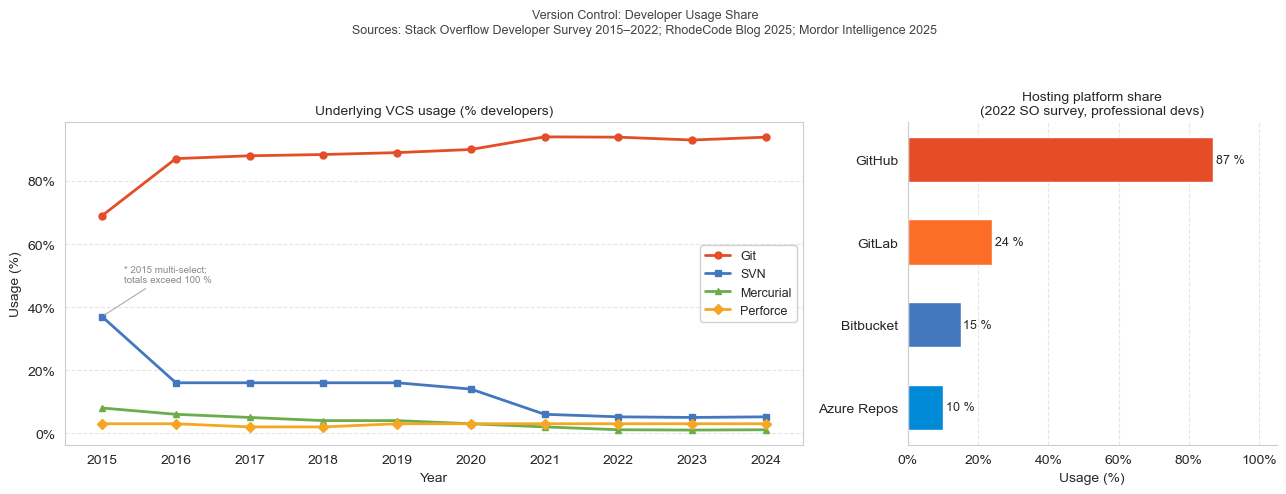

In [7]:
"""
VCS developer usage share (2015–2025) — two panels:
  1. Underlying VCS (Git, SVN, Mercurial, Perforce)
  2. Hosting platform market share (2022, professional developers)
 
Data sources:
  - Stack Overflow Developer Survey 2015–2022 (survey.stackoverflow.co)
  - Stack Overflow Blog, Jan 2023 (stackoverflow.blog)
  - RhodeCode Blog, Mar 2025 (rhodecode.com/blog/156)
  - Mordor Intelligence VCS Market Report 2025 (mordorintelligence.com)
 
Notes:
  - Pre-2022 figures are approximate; multi-select question inflates 2015 totals.
  - Azure Repos uses Git internally; its share is subsumed in the Git row.
  - Platform shares (panel 2) are from the 2022 SO survey (professional devs).
"""
 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
 
# ── 1. Underlying VCS usage (% of survey respondents) ───────────────────────
 
vcs_data = {
    "Year":       [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    "Git":        [69.0, 87.1, 88.0, 88.4, 89.0, 90.0, 94.0, 93.9, 93.0, 93.9],
    "SVN":        [37.0, 16.0, 16.0, 16.0, 16.0, 14.0,  6.0,  5.2,  5.0,  5.2],
    "Mercurial":  [ 8.0,  6.0,  5.0,  4.0,  4.0,  3.0,  2.0,  1.1,  1.0,  1.1],
    "Perforce":   [ 3.0,  3.0,  2.0,  2.0,  3.0,  3.0,  3.0,  3.0,  3.0,  3.0],
}
 
df_vcs = pd.DataFrame(vcs_data).set_index("Year")
 
# ── 2. Hosting platform share (2022 SO survey, professional developers) ──────
 
platform_data = {
    "Platform": ["GitHub", "GitLab", "Bitbucket", "Azure Repos"],
    "Share (%)": [87.0, 24.0, 15.0, 10.0],
}
df_platform = pd.DataFrame(platform_data).set_index("Platform")
 
# ── Plotting ─────────────────────────────────────────────────────────────────
 
fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5),
    gridspec_kw={"width_ratios": [2, 1]},
)
fig.suptitle(
    "Version Control: Developer Usage Share\n"
    "Sources: Stack Overflow Developer Survey 2015–2022; "
    "RhodeCode Blog 2025; Mordor Intelligence 2025",
    fontsize=9, color="#444444",
)
 
# ── Panel 1: time-series line chart ─────────────────────────────────────────
 
ax1 = axes[0]
 
colors = {
    "Git":       "#E44D26",
    "SVN":       "#4378BE",
    "Mercurial": "#6BAD4B",
    "Perforce":  "#F5A623",
}
markers = {"Git": "o", "SVN": "s", "Mercurial": "^", "Perforce": "D"}
 
for col in df_vcs.columns:
    ax1.plot(
        df_vcs.index, df_vcs[col],
        label=col,
        color=colors[col],
        marker=markers[col],
        linewidth=2,
        markersize=5,
    )
 
ax1.set_title("Underlying VCS usage (% developers)", fontsize=10)
ax1.set_xlabel("Year")
ax1.set_ylabel("Usage (%)")
ax1.set_xticks(df_vcs.index)
ax1.set_xlim(2014.5, 2024.5)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax1.legend(framealpha=0.9, fontsize=9)
ax1.grid(axis="y", linestyle="--", alpha=0.5)
ax1.annotate(
    "* 2015 multi-select;\ntotals exceed 100 %",
    xy=(2015, 37), xytext=(2015.3, 48),
    fontsize=7, color="#888888",
    arrowprops=dict(arrowstyle="-", color="#aaaaaa", lw=0.8),
)
 
# ── Panel 2: horizontal bar chart (2022 platform share) ─────────────────────
 
ax2 = axes[1]
 
bar_colors = ["#E44D26", "#FC6D26", "#4378BE", "#0089D6"]
bars = ax2.barh(
    df_platform.index,
    df_platform["Share (%)"],
    color=bar_colors,
    edgecolor="white",
    height=0.55,
)
 
for bar, val in zip(bars, df_platform["Share (%)"]):
    ax2.text(
        bar.get_width() + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.0f} %",
        va="center", fontsize=9,
    )
 
ax2.set_title("Hosting platform share\n(2022 SO survey, professional devs)", fontsize=10)
ax2.set_xlabel("Usage (%)")
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax2.set_xlim(0, 105)
ax2.invert_yaxis()
ax2.grid(axis="x", linestyle="--", alpha=0.5)
ax2.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)
 
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### Git servers
There are many servers available. These services include 
- Repository
- Issue tracking 
- Project management (Kanban tables etc.)

__Public__
- [GitHub](https://www.github.com)
- [GitLab](https://www.gitlab.com)
- [BitBucket](https://bitbucket.org/)

__Local__
- [ETH GitLab](https://gitlab.ethz.ch)
- [PSI Gitea](https://gitea.psi.ch)



## Repository workflows
- Single branch (like a backup server with comments)
- Multiple branches (Recommended)
<img src='figures/RepositoryNetwork.png' style="height:400px"/>


<div class="alert alert-success">
<center>Never commit to main branch unless the code is tested and reviewed.</center>
</div>

The recommended workflow when you work with a repository is to generously work with branches for each new sub task of the development. This make it easier to maintain a stable main branch that other people in the team can rely on to perform the tasks correctly and without crashing. The work in the branches are merged into the main after synchronization and review with a team mate.

```{figure} figures/RepositoryNetwork.png
---
width: 12cm
---
A snapshot of the branch network from a git repository.
```

[GitHub tutorials](https://guides.github.com)

## Continuous Integration
Continuous integration is the process of running tests automatically everytime changes are made. 

This is possible to setup inside of many IDEs and is offered as a commercial service from companies like CircleCI and Travis. Meanwhile, this is also an integrated service in GitHub which make it easier to set up as there no need for a third-party service account.


Projects like scikit-image use them to ensure changes that are made do not break existing code without requiring manual checks

<img src="figures/GHAction_fails.png" style="height:600px">

```{figure} figures/GHAction_fails.png
---
width: 12cm
---
Test reporting for GitHub Actions.
```

## A git demonstration

Using GitHub we will
- Create a repository
- Add some files and commit
- Push and pull
- Create and switch to new branch
- Make changes
- Merge branch into main 

# Summary

## Software engineering
- Documentation
- Unit testing
- Working with repositories
- Contiuous integration